In [1]:
from keras.preprocessing.image import ImageDataGenerator
import pickle
from keras.models import save_model, load_model
import numpy as np
from keras.preprocessing import image
import cv2 as cv
import matplotlib.pyplot as plt

In [2]:
path = '../face_cnn/'

In [3]:
TrainingImagePath= path+'face_img/train_img'

train_datagen = ImageDataGenerator(
        shear_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True)
 
# Defining pre-processing transformations on raw images of testing data
# No transformations are done on the testing images
test_datagen = ImageDataGenerator()
 
# Generating the Training Data
training_set = train_datagen.flow_from_directory(
        TrainingImagePath,
        target_size=(64, 64),
        batch_size=35,
        class_mode='categorical')
 
 
# Generating the Testing Data
test_set = test_datagen.flow_from_directory(
        TrainingImagePath,
        target_size=(64, 64),
        batch_size=35,
        class_mode='categorical')
 
# Printing class labels for each face
test_set.class_indices

Found 299 images belonging to 3 classes.
Found 299 images belonging to 3 classes.


{'Fajar_Amrullah': 0, 'M_Nurul_Karim': 1, 'Rusman_Tobyakta_Siregar': 2}

In [4]:
TrainClasses=training_set.class_indices

ResultMap={}
for faceValue,faceName in zip(TrainClasses.values(),TrainClasses.keys()):
    ResultMap[faceValue]=faceName.replace('_', ' ')


with open("ResultsMap.pkl", 'wb') as fileWriteStream:
    pickle.dump(ResultMap, fileWriteStream)
 
# The model will give answer as a numeric tag
# This mapping will help to get the corresponding face name for it
print("Mapping of Face and its ID",ResultMap)
 
# The number of neurons for the output layer is equal to the number of faces
OutputNeurons=len(ResultMap)
print('\n The Number of output neurons: ', OutputNeurons)

Mapping of Face and its ID {0: 'Fajar Amrullah', 1: 'M Nurul Karim', 2: 'Rusman Tobyakta Siregar'}

 The Number of output neurons:  3


In [5]:
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPool2D
from keras.layers import Flatten
from keras.layers import Dense

In [6]:
classifier= Sequential()

classifier.add(Convolution2D(32, kernel_size=(5, 5), strides=(1, 1), input_shape=(64,64,3), activation='relu'))

classifier.add(MaxPool2D(pool_size=(2,2)))

classifier.add(Convolution2D(64, kernel_size=(5, 5), strides=(1, 1), activation='relu'))
 
classifier.add(MaxPool2D(pool_size=(2,2)))
 
'''# STEP--3 FLattening'''
classifier.add(Flatten())
 
'''# STEP--4 Fully Connected Neural Network'''
classifier.add(Dense(64, activation='relu'))
 
classifier.add(Dense(OutputNeurons, activation='softmax'))
 
'''# Compiling the CNN'''
#classifier.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
classifier.compile(loss='categorical_crossentropy', optimizer = 'adam', metrics=["accuracy"])

classifier.summary()
###########################################################
import time
# Measuring the time taken by the model to train
StartTime=time.time()
# Starting the model training
classifier.fit(
                    training_set,
                    steps_per_epoch=50,
                    epochs=30,
                    validation_data=test_set,
                    validation_steps=10)
 
EndTime=time.time()
print("###### Total Time Taken: ", round((EndTime-StartTime)/60), 'Minutes ######')

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 60, 60, 32)        2432      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 30, 30, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 26, 26, 64)        51264     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 13, 13, 64)        0         
_________________________________________________________________
flatten (Flatten)            (None, 10816)             0         
_________________________________________________________________
dense (Dense)                (None, 64)                692288    
_________________________________________________________________
dense_1 (Dense)              (None, 3)                 1

In [7]:
print(classifier.history)
filepath = path+'faceModel.h5'
save_model(classifier, filepath, save_format='h5')
print(path+'faceModel.h5')

../face_cnn/faceModel.h5


########################################
Prediction is:  Rusman Tobyakta Siregar


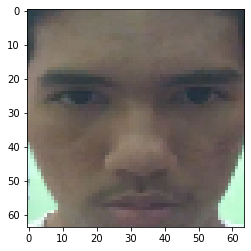

In [19]:
mdlFace = load_model(path+'faceModel.h5')
im = cv.imread(path+'face_img/test_img/rts2.jpg')

test_image = cv.resize(im, (64, 64))
test_image = test_image[...,::-1]
plt.imshow(test_image)
 
test_image=np.expand_dims(test_image,axis=0)
 
result=mdlFace.predict(test_image,verbose=0)
#print(max(result))
#print(training_set.class_indices)
#print(dir(mdlFace))
#print(mdlFace.history['accuracy'])
#print(result.sum(), result.std(), result.size)
#print(np.argmax(result))
print('####'*10)
print('Prediction is: ',ResultMap[np.argmax(result)])